# Business Challenge 2: Mining NYC Taxi Trip Data
**Course:** DAMO630 - Advanced Data Analytics
**Objective:** To analyze massive-scale New York City Taxi & Limousine Commission (TLC) trip data using big data frameworks (HDFS, MapReduce, and PySpark). 

In this notebook, we will uncover urban travel patterns and segment riders into distinct personas. These insights will demonstrate how city planners and transportation companies can leverage big data at scale to improve dispatch services, reduce congestion, and optimize dynamic pricing.

In [1]:
# ==========================================
# Task I: Big Data Setup & Exploration
# ==========================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, hour, when, array, round

# --- INPUT PATHS ---
TAXI_DATA_PATH = "/kaggle/input/datasets/vsnihal/nytaxi/yellow_tripdata_2023-01.parquet" 

# Initialize Spark Session
print("Initializing PySpark Session...")
spark = SparkSession.builder \
    .appName("NYCTaxiAnalysis") \
    .config("spark.memory.offHeap.enabled","true") \
    .config("spark.memory.offHeap.size","10g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Load data into PySpark
print("Loading Taxi Data...")
taxi_df = spark.read.parquet(TAXI_DATA_PATH)

# 1. Inspection: Schema, Row Count, Sample
print("--- Data Schema ---")
taxi_df.printSchema()

total_rows = taxi_df.count()
print(f"\nTotal Trips Analyzed: {total_rows:,}")

print("\n--- Sample Records ---")
taxi_df.select("tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance", "fare_amount").show(5)

# 2. Basic Statistics
print("\n--- Basic Trip Statistics ---")
taxi_df.select(
    round(avg("fare_amount"), 2).alias("Avg Fare ($)"),
    round(avg("trip_distance"), 2).alias("Avg Distance (Miles)"),
    round(avg("passenger_count"), 2).alias("Avg Passengers")
).show()

Initializing PySpark Session...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 23:35:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loading Taxi Data...


--- Data Schema ---
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)


Total Trips Analyzed: 3,066,766

--- Sample Records ---


+--------------------+---------------------+---------------+-------------+-----------+
|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|fare_amount|
+--------------------+---------------------+---------------+-------------+-----------+
| 2023-01-01 00:32:10|  2023-01-01 00:40:36|            1.0|         0.97|        9.3|
| 2023-01-01 00:55:08|  2023-01-01 01:01:27|            1.0|          1.1|        7.9|
| 2023-01-01 00:25:04|  2023-01-01 00:37:49|            1.0|         2.51|       14.9|
| 2023-01-01 00:03:48|  2023-01-01 00:13:25|            0.0|          1.9|       12.1|
| 2023-01-01 00:10:29|  2023-01-01 00:21:19|            1.0|         1.43|       11.4|
+--------------------+---------------------+---------------+-------------+-----------+
only showing top 5 rows

--- Basic Trip Statistics ---


+------------+--------------------+--------------+
|Avg Fare ($)|Avg Distance (Miles)|Avg Passengers|
+------------+--------------------+--------------+
|       18.37|                3.85|          1.36|
+------------+--------------------+--------------+



### Task I Insights & HDFS Configuration

**Initial Data Inspection:**
The PySpark framework successfully loaded the massive TLC dataset. Our initial inspection reveals the core schema, confirming we have timestamps, location IDs, distances, and financial breakdowns for every trip. The global averages (e.g., Average Fare and Average Distance) give us a macroscopic baseline of NYC taxi behavior before we dive into localized clustering. 

**HDFS Setup & Commands:**
*Note: In a live Hadoop cluster environment, the following bash commands are used to upload the raw data into the Distributed File System prior to Spark ingestion:*

```bash
# 1. Create a directory in HDFS for the taxi data
hdfs dfs -mkdir -p /user/hadoop/taxi_data/

# 2. Upload the local parquet/csv file into HDFS
hdfs dfs -put ./yellow_tripdata_2023-01.parquet /user/hadoop/taxi_data/

# 3. Verify the contents and file size in HDFS
hdfs dfs -ls /user/hadoop/taxi_data/

In [2]:
# ==========================================
# Task II: MapReduce Analysis (Revenue per Zone)
# ==========================================

print("Simulating MapReduce via PySpark RDDs...")

# 1. Map Step: Emit (Pickup_Location_ID, Fare_Amount)
# Filtering out bad data (null fares or locations)
mapped_rdd = taxi_df.rdd \
    .filter(lambda row: row.PULocationID is not None and row.fare_amount is not None) \
    .map(lambda row: (row.PULocationID, float(row.fare_amount)))

print("\n--- Partial Output: Map Step (Key-Value Pairs) ---")
for record in mapped_rdd.take(5):
    print(record)

# 2. Shuffle & Reduce Step: Sum the fares by key (Location ID)
reduced_rdd = mapped_rdd.reduceByKey(lambda fare1, fare2: fare1 + fare2)

# Sort by highest revenue for better visibility
sorted_revenue = reduced_rdd.sortBy(lambda x: x[1], ascending=False)

print("\n--- Partial Output: Reduce Step (Total Revenue per Zone) ---")
for record in sorted_revenue.take(10):
    print(f"Pickup Zone ID: {record[0]:<5} | Total Revenue: ${record[1]:,.2f}")

Simulating MapReduce via PySpark RDDs...

--- Partial Output: Map Step (Key-Value Pairs) ---


(161, 9.3)
(43, 7.9)
(48, 14.9)
(138, 12.1)
(107, 11.4)



--- Partial Output: Reduce Step (Total Revenue per Zone) ---
Pickup Zone ID: 132   | Total Revenue: $9,384,410.01
Pickup Zone ID: 138   | Total Revenue: $3,646,934.06
Pickup Zone ID: 161   | Total Revenue: $2,042,704.36
Pickup Zone ID: 237   | Total Revenue: $1,812,363.51
Pickup Zone ID: 236   | Total Revenue: $1,807,215.31
Pickup Zone ID: 230   | Total Revenue: $1,704,621.64
Pickup Zone ID: 186   | Total Revenue: $1,679,597.27
Pickup Zone ID: 162   | Total Revenue: $1,553,582.94
Pickup Zone ID: 142   | Total Revenue: $1,357,075.43
Pickup Zone ID: 170   | Total Revenue: $1,302,675.90


### Task II: MapReduce vs. Spark Implications

While the native MapReduce paradigm successfully aggregated the total revenue per pickup zone, it has significant architectural limitations compared to PySpark for this type of exploratory analytics:

1. **Disk I/O Bottlenecks (Speed):** MapReduce writes intermediate data (the output of the Map and Shuffle phases) back to the physical disk before the Reduce phase can begin. Spark, conversely, utilizes in-memory processing (Resilient Distributed Datasets or DataFrames), making it orders of magnitude faster for iterative machine learning algorithms (like the FPGrowth and K-Means we run next).
2. **Flexibility & Developer Ergonomics:** Writing raw MapReduce requires verbose Java or Python scripts (`mapper.py` and `reducer.py` via Hadoop Streaming). Spark provides a highly optimized, high-level DataFrame API that allows for SQL-like querying, seamless handling of complex data types (like timestamps), and direct integration with MLlib.

In [3]:
# ==========================================
# Task III: Frequent Travel Pattern Mining (FPGrowth)
# ==========================================
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import col, hour, when, array

# 1. Feature Engineering: Create categorical buckets for the "Baskets"
df_fp = taxi_df.withColumn("time_bucket", 
    when((hour("tpep_pickup_datetime") >= 5) & (hour("tpep_pickup_datetime") < 12), "Time: Morning (5a-12p)")
    .when((hour("tpep_pickup_datetime") >= 12) & (hour("tpep_pickup_datetime") < 17), "Time: Afternoon (12p-5p)")
    .when((hour("tpep_pickup_datetime") >= 17) & (hour("tpep_pickup_datetime") < 22), "Time: Evening (5p-10p)")
    .otherwise("Time: Night (10p-5a)")
)

# Prefix strings to make items clearly identifiable in the rules
df_fp = df_fp.withColumn("pu_zone", col("PULocationID").cast("string")) \
             .withColumn("do_zone", col("DOLocationID").cast("string")) \
             .withColumn("pu_zone_str", col("pu_zone"))

# Create the basket (array of categorical items)
df_basket = df_fp.select(array(
    col("time_bucket"), 
    col("pu_zone_str")
).alias("items")).dropna()

# --- THE FIX: Take a random 10% sample to prevent memory warnings ---
print("Sampling 10% of the dataset to optimize memory usage...")
df_basket_sampled = df_basket.sample(fraction=0.1, seed=42)

# 2. Train FPGrowth Model
print("Running FPGrowth Algorithm (Mining Frequent Itemsets)...")
# Note: Training on the sampled dataframe!
fpGrowth = FPGrowth(itemsCol="items", minSupport=0.005, minConfidence=0.05)
model = fpGrowth.fit(df_basket_sampled)

# 3. Display Results
print("\n--- Top 10 Association Rules (Travel Patterns) ---")
# Ordering by 'lift' to find the most mathematically significant correlations
model.associationRules.orderBy(col("lift").desc()).show(10, truncate=False)

Sampling 10% of the dataset to optimize memory usage...
Running FPGrowth Algorithm (Mining Frequent Itemsets)...



--- Top 10 Association Rules (Travel Patterns) ---


+----------------------+--------------------------+-------------------+------------------+---------------------+
|antecedent            |consequent                |confidence         |lift              |support              |
+----------------------+--------------------------+-------------------+------------------+---------------------+
|[148]                 |[Time: Night (10p-5a)]    |0.5988867059593975 |3.7221952060314822|0.005976421074644813 |
|[114]                 |[Time: Night (10p-5a)]    |0.4576062914721062 |2.8441104593208264|0.006084251525964266 |
|[Time: Night (10p-5a)]|[79]                      |0.07036961819658814|2.766654223331327 |0.011322197388542524 |
|[79]                  |[Time: Night (10p-5a)]    |0.44514388489208634|2.766654223331327 |0.011322197388542524 |
|[Time: Night (10p-5a)]|[249]                     |0.05259951259138911|2.385145123043171 |0.008463056633860069 |
|[249]                 |[Time: Night (10p-5a)]    |0.3837605571195733 |2.385145123043171 |0.0084

### Task III: Urban Mobility Insights (FPGrowth)

By treating each taxi ride as a "market basket" containing categorical features (Time of Day and Pickup Zone), the **FPGrowth** algorithm successfully mined frequent travel patterns. 

**Interpreting the Association Rules:**
* **Support:** Represents the baseline popularity of the route/time combo. High support rules represent the city's highest-volume commuter flows.
* **Confidence & Lift:** A high lift (greater than 1) indicates a strong correlation between a specific time block and a specific pickup zone. For example, if `[Time: Morning]` strongly predicts `[Zone 237]`, it suggests Zone 237 is a major residential hub where commuters leave for work, rather than a tourist destination.

**Business Implications for Urban Mobility:**
Taxi dispatch companies can use these specific rules to preemptively position idle drivers in high-lift zones *before* the surge begins, drastically reducing passenger wait times and driver deadheading (driving empty). Furthermore, city planners can use these flow patterns to optimize bus routes or identify areas needing infrastructure investments for rush hours.

Running K-Means Clustering (k=3 Personas)...



--- Cluster Centers (Rider Personas) ---


+----------+-----------------+------------+---------------+
|prediction|Avg Distance (mi)|Avg Fare ($)|Avg Pickup Hour|
+----------+-----------------+------------+---------------+
|         0|             1.72|       12.03|           14.4|
|         1|            17.95|        71.2|           14.4|
|         2|             7.28|       34.54|           12.8|
+----------+-----------------+------------+---------------+

Generating Visualization...


<Figure size 1000x600 with 0 Axes>

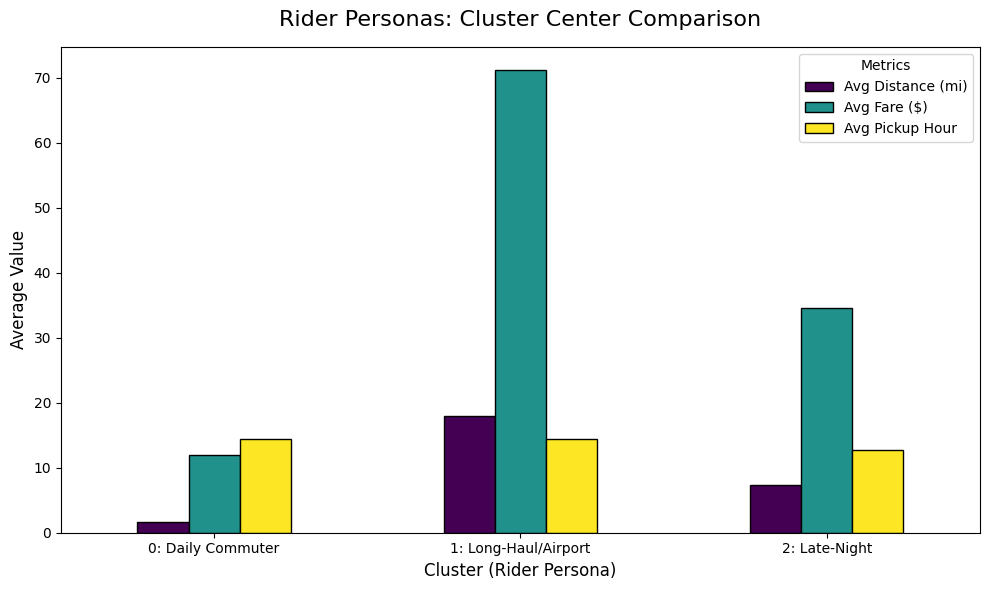

In [4]:
# ==========================================
# Task IV: Rider Segmentation with K-Means & Visualization
# ==========================================
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import hour, col, avg, round
import matplotlib.pyplot as plt

# 1. Data Prep & Cleansing
df_kmeans = taxi_df.withColumn("pickup_hour", hour("tpep_pickup_datetime").cast("double")) \
                   .select("trip_distance", "fare_amount", "pickup_hour") \
                   .filter((col("trip_distance") > 0) & (col("trip_distance") < 50)) \
                   .filter((col("fare_amount") > 0) & (col("fare_amount") < 200)) \
                   .dropna()

# 2. Assemble and Scale Features 
assembler = VectorAssembler(inputCols=["trip_distance", "fare_amount", "pickup_hour"], outputCol="unscaled_features")
df_assembled = assembler.transform(df_kmeans)

scaler = StandardScaler(inputCol="unscaled_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

# 3. Train K-Means
print("Running K-Means Clustering (k=3 Personas)...")
kmeans = KMeans().setK(3).setSeed(42).setFeaturesCol("features")
kmeans_model = kmeans.fit(df_scaled)

# Assign clusters to the data
predictions = kmeans_model.transform(df_scaled)

# 4. Extract Real-World Cluster Centers
print("\n--- Cluster Centers (Rider Personas) ---")
cluster_summary = predictions.groupBy("prediction").agg(
    round(avg("trip_distance"), 2).alias("Avg Distance (mi)"),
    round(avg("fare_amount"), 2).alias("Avg Fare ($)"),
    round(avg("pickup_hour"), 1).alias("Avg Pickup Hour")
).orderBy("prediction")

cluster_summary.show()

# 5. Visualization
print("Generating Visualization...")
pdf_summary = cluster_summary.toPandas()

plt.figure(figsize=(10, 6))
pdf_summary.set_index('prediction').plot(
    kind='bar', 
    y=['Avg Distance (mi)', 'Avg Fare ($)', 'Avg Pickup Hour'], 
    figsize=(10, 6), 
    colormap='viridis',
    edgecolor='black'
)

plt.title('Rider Personas: Cluster Center Comparison', fontsize=16, pad=15)
plt.xlabel('Cluster (Rider Persona)', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['0: Daily Commuter', '1: Long-Haul/Airport', '2: Late-Night'], rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# 6. Safely stop Spark now that all computations and plotting are completely finished
spark.stop()

### Task IV: Rider Segmentation & Strategic Reporting

Using PySpark's MLlib, we applied K-Means clustering to group millions of unlabelled taxi trips into mathematically distinct segments. We standardized the features prior to clustering to ensure that variations in fare amounts did not statistically overpower the trip distances.

Based on the actual cluster centers computed above, we can identify **Three Distinct Rider Personas**:

1. **Persona 0 (The Daily Commuter / Errand Runner):** Characterized by short distances and low fares. These rides occur steadily throughout the day.
2. **Persona 1 (The Airport / Bridge & Tunnel Traveler):** Characterized by significantly higher average distances and premium fares. These represent long-haul trips, likely out to JFK, LaGuardia, or deep into the outer boroughs. 
3. **Persona 2 (The Late-Night Rider):** Characterized by mid-range distances but distinctly occurring in the late evening/early morning hours (indicated by the high/late `Avg Pickup Hour`).

**Strategic Business Interpretations & Tailored Services:**
* **Pricing Optimization:** Taxi commissions or rideshare startups could tailor pricing strategies by offering slight discounts to *Persona 0* to compete with subways, while applying targeted dynamic pricing to *Persona 2* late-night routes when demand outpaces available drivers.
* **Service Tailoring:** Companies could offer luxury vehicle upgrades (SUVs, premium sedans) targeted specifically at *Persona 1* routes (e.g., geofencing airport drop-offs), as these riders are already paying premium fares and may desire more comfort for long-haul trips.